In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
np.set_printoptions(precision=5, suppress=True, linewidth=100)
plt.rcParams['figure.dpi'] = 150
import tenpy
import tenpy.linalg.np_conserved as npc
from tenpy.algorithms import dmrg
from tenpy.networks.mps import MPS
from tenpy.models.tf_ising import TFIChain
import tenpy
from tenpy.networks.site import SpinSite
from tenpy.networks.mps import TransferMatrix
from tenpy.models.model import CouplingMPOModel, NearestNeighborModel
from tenpy.models.lattice import Chain
from tenpy.linalg import np_conserved as npc
import numpy as np
tenpy.tools.misc.setup_logging(to_stdout="INFO")

from tenpy.models.lattice import Lattice
from tenpy.models.model import CouplingModel,MPOModel
from tenpy.networks.site import SpinHalfSite, kron

import MPSToolBox as my

Imported MPSToolBox


# XY model

In [ ]:
E, psi, M = my.mydmrg1(my.XXZModel, [2,1], params=None, chi=300, init_state=[[1, 0],[1, 0]], bc_MPS='infinite',bc1='periodic', max_sweeps=200, sitetype=SpinHalfSite, conserve=None, svd_min=1.e-13, max_E_err=1.e-10, to_stdout="INFO")

INFO    : XXZModel: reading 'lattice'=<tenpy.models.lattice.Lattice object at 0x7c565b287390>
  warnings.warn(msg.format(keys=sorted(unused), name=self.name))

INFO    : TwoSiteDMRGEngine: subconfig 'trunc_params'=Config(<2 options>, 'trunc_params')
INFO    : TwoSiteDMRGEngine: reading 'combine'=True
INFO    : TwoSiteDMRGEngine: reading 'chi_list'={0: 10, 20: 20, 40: 50, 60: 100, 80: 120, 100: 150, 120: 200, 140: 250, 160: 300, 180: 300}
INFO    : start environment_sweep
INFO    : trunc_params: reading 'chi_max'=300
INFO    : trunc_params: reading 'svd_min'=1e-13
INFO    : TwoSiteDMRGEngine: subconfig 'mixer_params'=Config(<2 options>, 'mixer_params')
INFO    : TwoSiteDMRGEngine: reading 'mixer'=True
INFO    : activate DensityMatrixMixer with initial amplitude 1e-05
INFO    : TwoSiteDMRGEngine: reading 'max_sweeps'=200
INFO    : Running sweep with optimization
INFO    : Setting chi_max=10
INFO    : activate DensityMatrixMixer with initial amplitude 1e-05
INFO    : Disable mixer after 5

In [7]:
L = 100
x = np.arange(2,L,2)

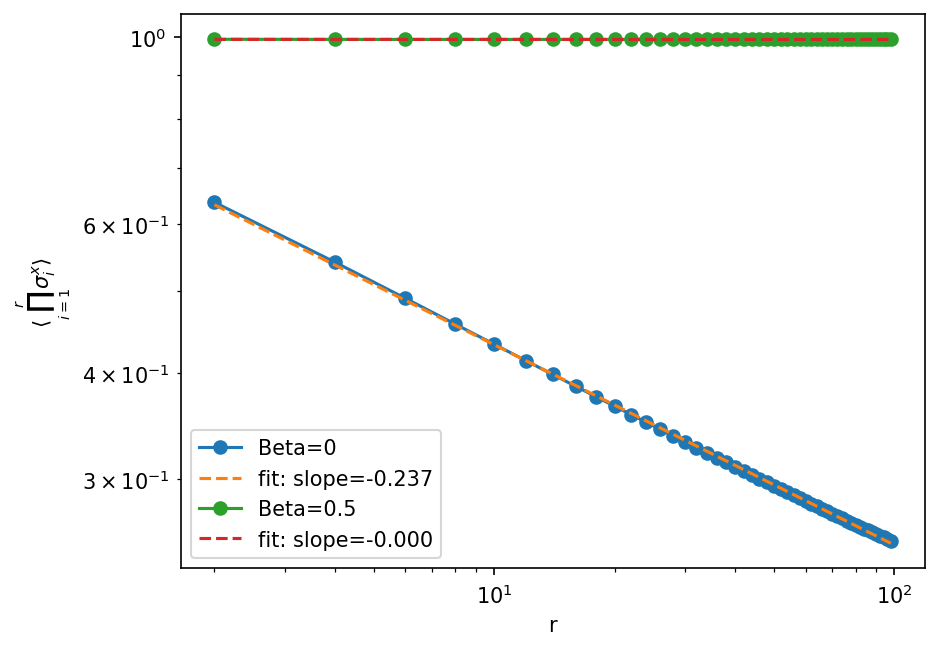

In [25]:
for beta in [0, 0.5]:
    L = 100
    x = np.arange(2,L,2)
    gates = [my.expm(beta * my.sX)]*2
    psi_measured = my.gate_onsite1(psi, gates, [0,1])
    psi_measured.canonical_form()
    
    Y_prod = [psi_measured.expectation_value_multi_sites(['Sigmax']*i, i0=0) for i in x]

    plt.loglog(x, Y_prod, 'o-', label=f'Beta={beta}')
    poly = np.polyfit(np.log(x), np.log(Y_prod), 1)
    plt.loglog(x, np.exp(poly[1]) * x**poly[0], '--', label=f'fit: slope={poly[0]:.3f}')
plt.xlabel('r')
plt.ylabel(r'$\langle \prod_{i=1}^r \sigma^x_i \rangle$')
plt.legend()
plt.show()

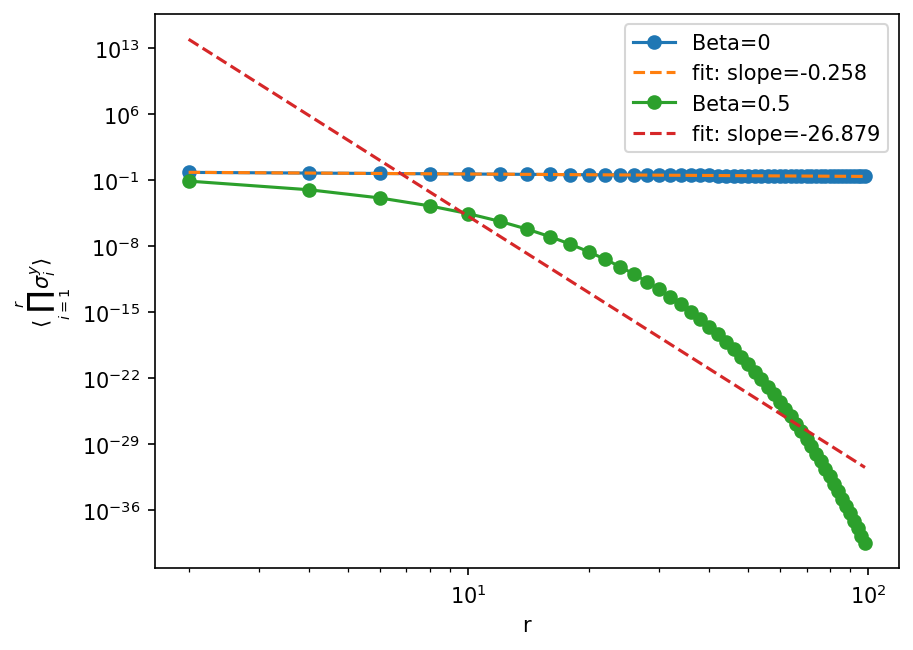

In [23]:
for beta in [0, 0.5]:
    L = 100
    x = np.arange(2,L,2)
    gates = [my.expm(beta * my.sX)]*2
    psi_measured = my.gate_onsite1(psi, gates, [0,1])
    psi_measured.canonical_form()
    
    Y_prod = [psi_measured.expectation_value_multi_sites(['Sigmay']*i, i0=0) for i in x]

    plt.loglog(x, Y_prod, 'o-', label=f'Beta={beta}')
    poly = np.polyfit(np.log(x), np.log(Y_prod), 1)
    plt.loglog(x, np.exp(poly[1]) * x**poly[0], '--', label=f'fit: slope={poly[0]:.3f}')
plt.xlabel('r')
plt.ylabel(r'$\langle \prod_{i=1}^r \sigma^y_i \rangle$')
plt.legend()
plt.show()

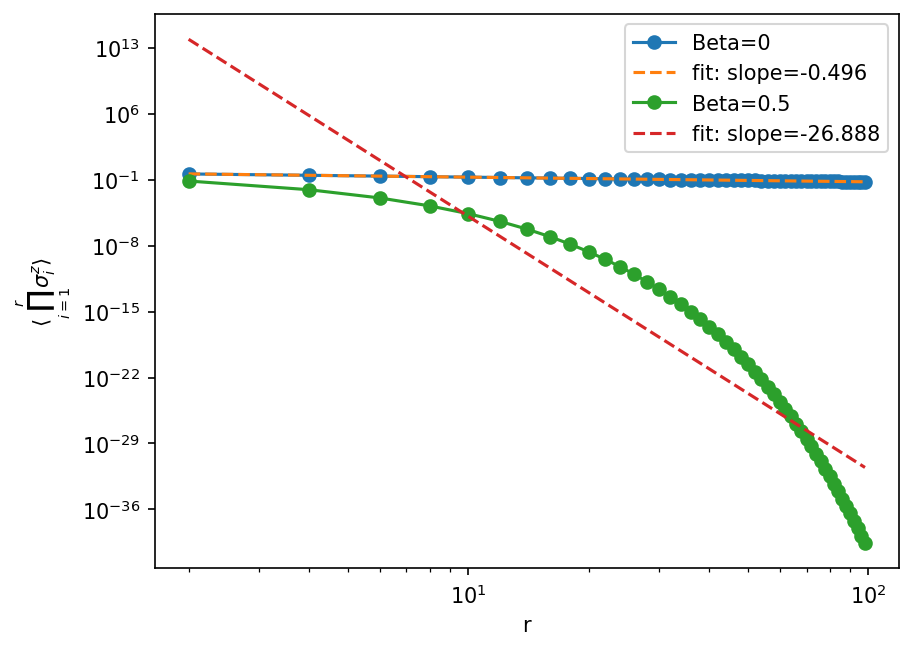

In [28]:
for beta in [0, 0.5]:
    L = 100
    x = np.arange(2,L,2)
    gates = [my.expm(beta * my.sX)]*2
    psi_measured = my.gate_onsite1(psi, gates, [0,1])
    psi_measured.canonical_form()
    
    Y_prod = np.abs([psi_measured.expectation_value_multi_sites(['Sigmaz']*i, i0=0) for i in x])

    plt.loglog(x, Y_prod, 'o-', label=f'Beta={beta}')
    poly = np.polyfit(np.log(x), np.log(Y_prod), 1)
    plt.loglog(x, np.exp(poly[1]) * x**poly[0], '--', label=f'fit: slope={poly[0]:.3f}')
plt.xlabel('r')
plt.ylabel(r'$\langle \prod_{i=1}^r \sigma^z_i \rangle$')
plt.legend()
plt.show()

# Ising^2

In [2]:
psi = my.load_pkl("../wavefunctions/Isingladder_L40_PBC_chi300.pkl")
L = 40

In [4]:
beta = 0.3
# gate = my.kron(npc.expm(beta * psi.sites[0].Sigmaz), npc.expm(beta * psi.sites[0].Sigmaz)).split_legs()
gate = npc.expm(beta * my.kron(psi.sites[0].Sigmaz, psi.sites[1].Sigmaz)).split_legs()

In [5]:
psi_measured = my.gate_twosite_nonoverlap(psi, [gate]*L, np.arange(0,2*L,2),cutoff=1e-10)
psi_measured.canonical_form()

In [6]:
print(psi_measured.expectation_value('Sigmaz')) # it breaks the symmetry...

[0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001
 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001
 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001
 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001
 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001
 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001
 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001 0.00001]


In [7]:
L = 40
x = np.arange(1,L-1)
x_chord = my.chord(x=x, L=L)
# y = [np.abs(psi_measured.expectation_value_multi_sites(['Sigmax', 'Sigmax']*i, i0=0)) for i in x]

y = [np.abs(psi_measured.expectation_value_multi_sites(['Sigmaz', 'Sigmaz'] + ['Id', 'Id']* (i-1) + ['Sigmaz', 'Sigmaz'], i0=0)) for i in x]

disconnected = [psi_measured.expectation_value_multi_sites(['Sigmaz', 'Sigmaz'], i0=0) * psi_measured.expectation_value_multi_sites(['Sigmaz', 'Sigmaz'], i0=i) for i in x]

y = np.array(y) - np.array(disconnected)

# y = psi_measured.correlation_function('Sigmaz', 'Sigmaz', [0], 2*x)[0]

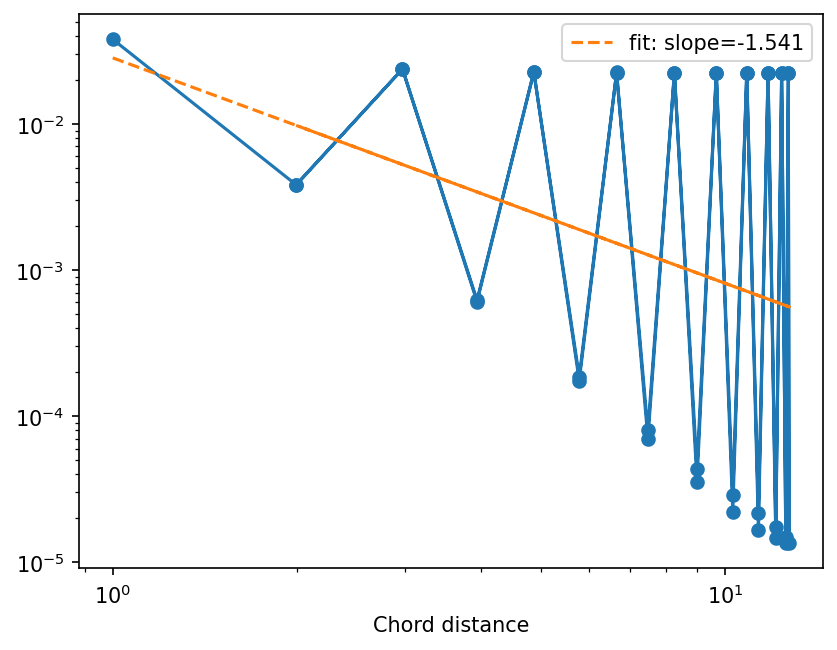

In [8]:
plt.loglog(x_chord, y, 'o-')
poly = np.polyfit(np.log(x_chord), np.log(y), 1)
plt.loglog(x_chord, np.exp(poly[1]) * x_chord**poly[0], '--', label=f'fit: slope={poly[0]:.3f}')

plt.xlabel('Chord distance')
# plt.ylabel(r'$\langle \sigma^z_i \sigma^z_{i+r} \rangle$')
plt.legend()
plt.show()

In [9]:
L = 40
x = np.arange(1,L-1)
x_chord = my.chord(x=x, L=L)
# y = [np.abs(psi_measured.expectation_value_multi_sites(['Sigmax', 'Sigmax']*i, i0=0)) for i in x]

y = [np.abs(psi_measured.expectation_value_multi_sites(['Sigmaz', 'Sigmaz'] + ['Id', 'Id']* (i-1) + ['Sigmaz', 'Sigmaz'], i0=0)) for i in x]

disconnected = [psi_measured.expectation_value_multi_sites(['Sigmaz', 'Sigmaz'], i0=0) * psi_measured.expectation_value_multi_sites(['Sigmaz', 'Sigmaz'], i0=i) for i in x]

y = np.array(y) - np.array(disconnected)


In [10]:
L = 40
x = np.arange(1,L-1)
x_chord = my.chord(x=x, L=L)

In [11]:
2 * (psi_measured.expectation_value("Sigmaz",1) - psi_measured.expectation_value("Sigmaz",0))

array([0.])

In [12]:
y = psi_measured.correlation_function('Sigmaz', 'Sigmaz', [0], 2*x)[0] + psi_measured.correlation_function('Sigmaz', 'Sigmaz', [1], 2*x+1)[0] - psi_measured.correlation_function('Sigmaz', 'Sigmaz', [0], 2*x+1)[0] - psi_measured.correlation_function('Sigmaz', 'Sigmaz', [1], 2*x)[0]

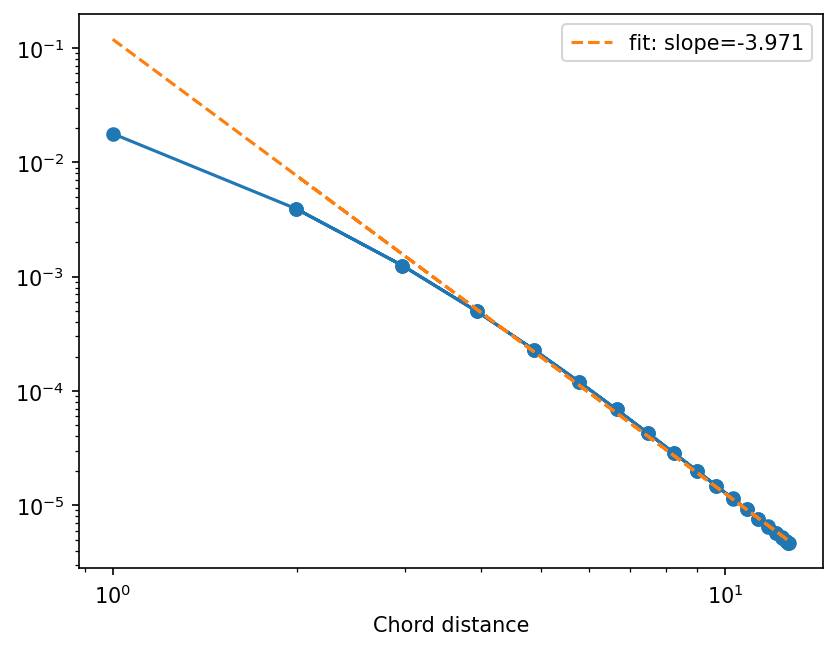

In [13]:
plt.loglog(x_chord, y, 'o-')

fit_ind = np.arange(2, len(x_chord)-2)

poly = np.polyfit(np.log(x_chord[fit_ind]), np.log(y[fit_ind]), 1)
plt.loglog(x_chord, np.exp(poly[1]) * x_chord**poly[0], '--', label=f'fit: slope={poly[0]:.3f}')

plt.xlabel('Chord distance')
# plt.ylabel(r'$\langle \sigma^z_i \sigma^z_{i+r} \rangle$')
plt.legend()
plt.show()

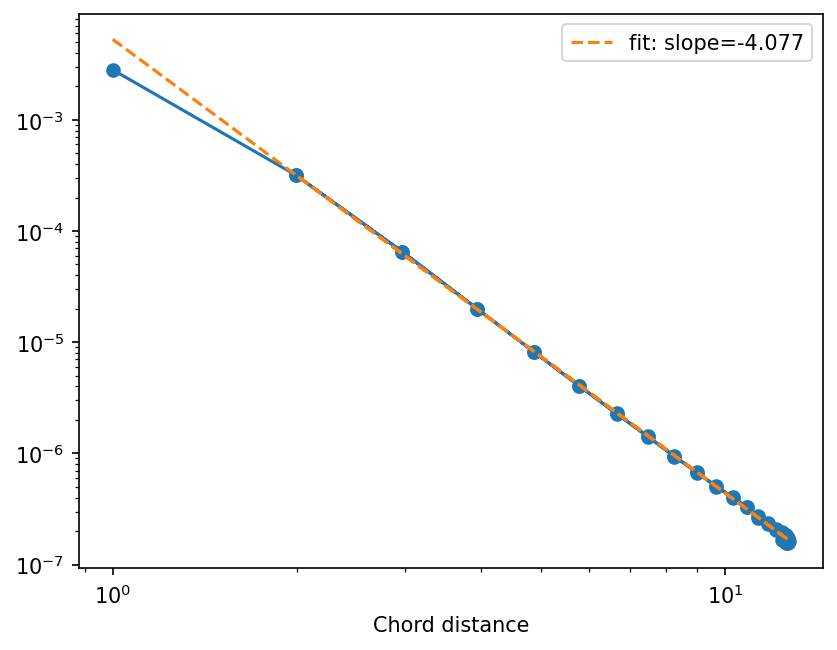

In [14]:
L = 40
x = np.arange(1,L-1)
x_chord = my.chord(x=x, L=L)

beta = 0.5
gate = my.kron(npc.expm(beta * psi.sites[0].Sigmaz), npc.expm(beta * psi.sites[0].Sigmaz)).split_legs()
psi_measured = my.gate_twosite_nonoverlap(psi, [gate]*L, np.arange(0,2*L,2),cutoff=1e-10)
psi_measured.canonical_form()

y = psi_measured.correlation_function('Sigmaz', 'Sigmaz', [0], 2*x)[0] + psi_measured.correlation_function('Sigmaz', 'Sigmaz', [1], 2*x+1)[0] - psi_measured.correlation_function('Sigmaz', 'Sigmaz', [0], 2*x+1)[0] - psi_measured.correlation_function('Sigmaz', 'Sigmaz', [1], 2*x)[0]

plt.loglog(x_chord, y, 'o-')

fit_ind = np.arange(2, len(x_chord)-2)

poly = np.polyfit(np.log(x_chord[fit_ind]), np.log(y[fit_ind]), 1)
plt.loglog(x_chord, np.exp(poly[1]) * x_chord**poly[0], '--', label=f'fit: slope={poly[0]:.3f}')

plt.xlabel('Chord distance')
# plt.ylabel(r'$\langle \sigma^z_i \sigma^z_{i+r} \rangle$')
plt.legend()
plt.show()

In [15]:
psi_measured.expectation_value("Sigmaz",0), psi_measured.expectation_value("Sigmaz",1)

(array([0.97848]), array([0.97848]))

In [29]:
# 2-leg ladder model: explicit 80-site MPS (40 rungs), decoupled critical Ising chains
from tenpy.models.lattice import Ladder
from tenpy.networks.site import set_common_charges

class TwoLegTFILadder(CouplingMPOModel):
    """Two decoupled TFI chains on a ladder with Z2 x Z2 parity conservation."""
    default_lattice = Ladder
    force_default_lattice = True

    def init_sites(self, model_params):
        conserve = model_params.get('conserve', 'parity')
        sort_charge = model_params.get('sort_charge', True)
        siteA = SpinHalfSite(conserve=conserve, sort_charge=sort_charge)
        siteB = SpinHalfSite(conserve=conserve, sort_charge=sort_charge)
        # Make the two parities independent: Z2 (leg A) x Z2 (leg B)
        if conserve == 'parity' and model_params.get('separate_z2', True):
            set_common_charges([siteA, siteB], new_charges='independent',
                               new_names=['parity_A', 'parity_B'])
        return [siteA, siteB]

    def init_terms(self, model_params):
        J = model_params.get('J', 1.0)
        g = model_params.get('g', 1.0)
        # Field along z (diagonal in Sz).
        for u in range(len(self.lat.unit_cell)):
            self.add_onsite(-g, u, 'Sigmaz')
        # Leg couplings only (no rungs): two decoupled chains.
        for u1, u2, dx in self.lat.pairs['leg_NN']:
            self.add_coupling(-J, u1, 'Sigmax', u2, 'Sigmax', dx)

L = 40
model_params = dict(
    L=L,
    J=1.0,
    g=1.0,  # critical point
    conserve='parity',
    separate_z2=True,
    bc_MPS='finite',
    bc_x='periodic',
    order='default',
)

M = TwoLegTFILadder(model_params)
print('Total sites:', M.lat.N_sites)

# Even-even sector for both parities (L is even): all |up> in Sz basis.
product_state = ['up'] * M.lat.N_sites
psi = MPS.from_product_state(M.lat.mps_sites(), product_state, bc=M.lat.bc_MPS)
psi.canonical_form()

dmrg_params = dict(
    mixer=True,
    max_E_err=1e-10,
    trunc_params=dict(chi_max=300, svd_min=1e-12),
    combine=True,
    max_sweeps=60,
)

info = dmrg.run(psi, M, dmrg_params)
E = info['E']
# psi is updated in-place by dmrg.run; keep an explicit handle
psi_gs = psi.copy()
print('Ground state energy:', E)


INFO    : TwoLegTFILadder: reading 'bc_MPS'='finite'
INFO    : TwoLegTFILadder: reading 'order'='default'
INFO    : TwoLegTFILadder: reading 'conserve'='parity'
INFO    : TwoLegTFILadder: reading 'separate_z2'=True
INFO    : TwoLegTFILadder: reading 'bc_x'='periodic'
INFO    : TwoLegTFILadder: reading 'L'=40
INFO    : TwoLegTFILadder: reading 'J'=1.0
INFO    : TwoLegTFILadder: reading 'g'=1.0
Total sites: 80
INFO    : DMRG: subconfig 'trunc_params'=Config(<2 options>, 'trunc_params')
INFO    : DMRG: reading 'combine'=True
INFO    : DMRG: reading 'mixer'=True
INFO    : activate DensityMatrixMixer with initial amplitude 1e-05
INFO    : DMRG: reading 'max_sweeps'=60
INFO    : Running sweep with optimization
INFO    : trunc_params: reading 'chi_max'=300
INFO    : trunc_params: reading 'svd_min'=1e-12
INFO    : checkpoint after sweep 1
energy=-101.7592424049559696, max S=1.1180749494694178, age=80, norm_err=3.5e-01
Current memory usage 525.7MB, wall time: 2.2s
Delta E = nan, Delta S = 7.189

In [31]:
my.save_pkl(psi_gs, "./temp/Isingladder_L40_PBC_chi300_symmetry.pkl")

In [16]:
psi = my.load_pkl("./temp/Isingladder_L40_PBC_chi300_symmetry.pkl")

In [18]:
L = 40
x = np.arange(1,L-1)
x_chord = my.chord(x=x, L=L)

beta = 0.5
gate = my.kron(npc.expm(beta * psi.sites[0].Sigmax), npc.expm(beta * psi.sites[1].Sigmax)).split_legs()
psi_measured = my.gate_twosite_nonoverlap(psi, [gate]*L, np.arange(0,2*L,2),cutoff=1e-10)
psi_measured.canonical_form()

y = psi_measured.correlation_function('Sigmax', 'Sigmax', [0], 2*x)[0] + psi_measured.correlation_function('Sigmax', 'Sigmax', [1], 2*x+1)[0] - psi_measured.correlation_function('Sigmax', 'Sigmax', [0], 2*x+1)[0] - psi_measured.correlation_function('Sigmax', 'Sigmax', [1], 2*x)[0]

plt.loglog(x_chord, y, 'o-')

fit_ind = np.arange(2, len(x_chord)-2)

poly = np.polyfit(np.log(x_chord[fit_ind]), np.log(y[fit_ind]), 1)
plt.loglog(x_chord, np.exp(poly[1]) * x_chord**poly[0], '--', label=f'fit: slope={poly[0]:.3f}')

plt.xlabel('Chord distance')
# plt.ylabel(r'$\langle \sigma^x_i \sigma^x_{i+r} \rangle$')
plt.legend()
plt.show()

NotImplementedError: A*A has different qtotal than A; nilpotent matrix

In [21]:
from tenpy.models.lattice import Ladder
from tenpy.models.model import CouplingMPOModel
from tenpy.networks.site import SpinHalfSite
from tenpy.algorithms import dmrg
from tenpy.networks.mps import MPS

# DMRG with only the combined Z2 parity (single parity charge)
class TwoLegTFILadderCombinedZ2(CouplingMPOModel):
    """Two-leg TFI ladder with only combined Z2 parity conserved."""
    default_lattice = Ladder
    force_default_lattice = True

    def init_sites(self, model_params):
        conserve = model_params.get('conserve', 'parity')
        sort_charge = model_params.get('sort_charge', True)
        # Use the same parity charge on both legs (combined parity only).
        siteA = SpinHalfSite(conserve=conserve, sort_charge=sort_charge)
        siteB = SpinHalfSite(conserve=conserve, sort_charge=sort_charge)
        return [siteA, siteB]

    def init_terms(self, model_params):
        J = model_params.get('J', 1.0)
        g = model_params.get('g', 1.0)
        for u in range(len(self.lat.unit_cell)):
            self.add_onsite(-g, u, 'Sigmaz')
        for u1, u2, dx in self.lat.pairs['leg_NN']:
            self.add_coupling(-J, u1, 'Sigmax', u2, 'Sigmax', dx)

L = 40
model_params = dict(
    L=L,
    J=1.0,
    g=1.0,
    conserve='parity',
    bc_MPS='finite',
    bc_x='periodic',
    order='default',
)

M = TwoLegTFILadderCombinedZ2(model_params)
print('Total sites:', M.lat.N_sites)

product_state = ['up'] * M.lat.N_sites
psi = MPS.from_product_state(M.lat.mps_sites(), product_state, bc=M.lat.bc_MPS)
psi.canonical_form()

dmrg_params = dict(
    mixer=True,
    max_E_err=1e-10,
    trunc_params=dict(chi_max=300, svd_min=1e-12),
    combine=True,
    max_sweeps=60,
)

info = dmrg.run(psi, M, dmrg_params)
E = info['E']
psi_gs = psi.copy()
print('Ground state energy:', E)


INFO    : TwoLegTFILadderCombinedZ2: reading 'bc_MPS'='finite'
INFO    : TwoLegTFILadderCombinedZ2: reading 'order'='default'
INFO    : TwoLegTFILadderCombinedZ2: reading 'conserve'='parity'
INFO    : TwoLegTFILadderCombinedZ2: reading 'bc_x'='periodic'
INFO    : TwoLegTFILadderCombinedZ2: reading 'L'=40
INFO    : TwoLegTFILadderCombinedZ2: reading 'J'=1.0
INFO    : TwoLegTFILadderCombinedZ2: reading 'g'=1.0
Total sites: 80
INFO    : DMRG: subconfig 'trunc_params'=Config(<2 options>, 'trunc_params')
INFO    : DMRG: reading 'combine'=True
INFO    : DMRG: reading 'mixer'=True
INFO    : activate DensityMatrixMixer with initial amplitude 1e-05
INFO    : DMRG: reading 'max_sweeps'=60
INFO    : Running sweep with optimization
INFO    : trunc_params: reading 'chi_max'=300
INFO    : trunc_params: reading 'svd_min'=1e-12
INFO    : checkpoint after sweep 1
energy=-101.7712361145519679, max S=1.1443963476511654, age=80, norm_err=3.5e-01
Current memory usage 609.3MB, wall time: 3.1s
Delta E = nan,

In [24]:
psi_gs

In [22]:
my.save_pkl(psi_gs, "./temp/Isingladder_L40_PBC_chi300_diagonalsymmetry.pkl")

In [33]:
len(psi_gs.sites)

80

In [34]:
# Apply exp(beta X_1 X_2) on each rung to the ground state (combined Z2 parity only)
beta = 0.3

psi_rung = psi_gs.copy()
# Group sites into rungs: each site is (A_i, B_i)
psi_rung.group_sites(n=2)

# Build rung gate on the grouped site
rung_op = psi_rung.sites[0].get_op('Sigmax0 Sigmax1')
rung_gate = npc.expm(beta * rung_op)

for i in range(psi_rung.L):
    print(f'Applying rung gate on rung {i}...')
    psi_rung.apply_local_op(i, rung_gate, unitary=False)

# Split back to 80-site MPS
trunc_err = psi_rung.group_split(trunc_par={'chi_max': 300})
psi_rung.canonical_form()
print('group_split truncation error:', trunc_err)

# Check that <X_1> and <X_2> remain zero by symmetry (up to numerical error)
X1_mean = np.mean([psi_rung.expectation_value('Sigmax', i) for i in range(0, psi_rung.L, 2)])
X2_mean = np.mean([psi_rung.expectation_value('Sigmax', i) for i in range(1, psi_rung.L, 2)])
print('mean <X_1>:', X1_mean)
print('mean <X_2>:', X2_mean)

my.save_pkl(psi_rung, f"./temp/Isingladder_L40_PBC_chi300_diagonalsymmetry_beta{beta}.pkl")


Applying rung gate on rung 0...
Applying rung gate on rung 1...
Applying rung gate on rung 2...
Applying rung gate on rung 3...
Applying rung gate on rung 4...
Applying rung gate on rung 5...
Applying rung gate on rung 6...
Applying rung gate on rung 7...
Applying rung gate on rung 8...
Applying rung gate on rung 9...
Applying rung gate on rung 10...
Applying rung gate on rung 11...
Applying rung gate on rung 12...
Applying rung gate on rung 13...
Applying rung gate on rung 14...
Applying rung gate on rung 15...
Applying rung gate on rung 16...
Applying rung gate on rung 17...
Applying rung gate on rung 18...
Applying rung gate on rung 19...
Applying rung gate on rung 20...
Applying rung gate on rung 21...
Applying rung gate on rung 22...
Applying rung gate on rung 23...
Applying rung gate on rung 24...
Applying rung gate on rung 25...
Applying rung gate on rung 26...
Applying rung gate on rung 27...
Applying rung gate on rung 28...
Applying rung gate on rung 29...
Applying rung gate o

In [35]:
psi_rung.expectation_value('Sigmax', 0), psi_rung.expectation_value('Sigmax', 1)

(array([0.]), array([0.]))

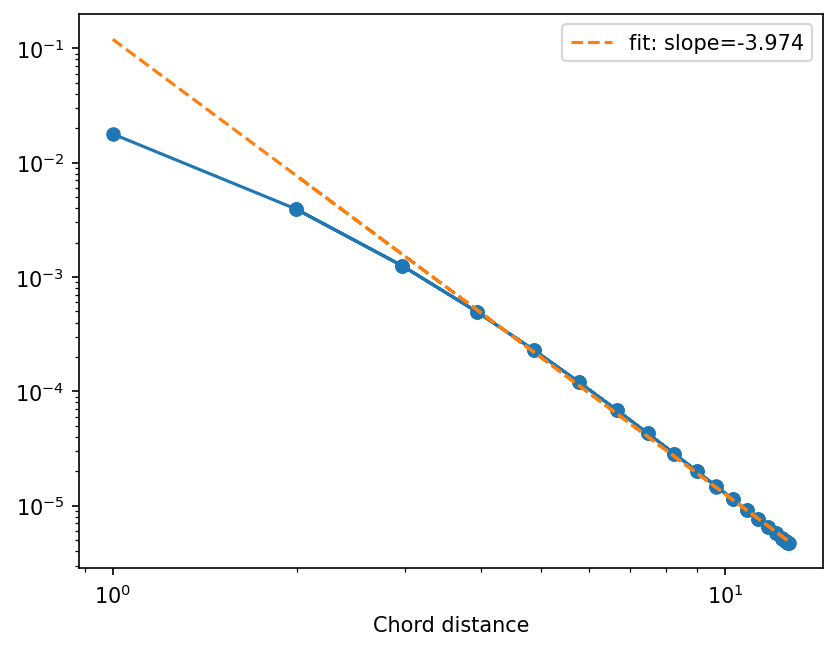

In [36]:
L = 40
x = np.arange(1,L-1)
x_chord = my.chord(x=x, L=L)

beta = 0.3

psi_measured = my.load_pkl(f"./temp/Isingladder_L40_PBC_chi300_diagonalsymmetry_beta{beta}.pkl")
y = psi_measured.correlation_function('Sigmax', 'Sigmax', [0], 2*x)[0] + psi_measured.correlation_function('Sigmax', 'Sigmax', [1], 2*x+1)[0] - psi_measured.correlation_function('Sigmax', 'Sigmax', [0], 2*x+1)[0] - psi_measured.correlation_function('Sigmax', 'Sigmax', [1], 2*x)[0]

plt.loglog(x_chord, y, 'o-')

fit_ind = np.arange(2, len(x_chord)-2)

poly = np.polyfit(np.log(x_chord[fit_ind]), np.log(y[fit_ind]), 1)
plt.loglog(x_chord, np.exp(poly[1]) * x_chord**poly[0], '--', label=f'fit: slope={poly[0]:.3f}')

plt.xlabel('Chord distance')
# plt.ylabel(r'$\langle \sigma^x_i \sigma^x_{i+r} \rangle$')
plt.legend()
plt.show()